# Modelling a Type I and Type II AGN

In [3]:
import numpy as np
from unyt import K, Mpc, Msun, deg, yr, cm, Myr, c, Msun, Angstrom

from synthesizer import Grid
from synthesizer.emission_models import (
    AttenuatedEmission,
    DustEmission,
    UnifiedAGN,
    IntrinsicEmission,
    EmissionModel,
    BLREmission,
)
from synthesizer.emission_models.attenuation import PowerLaw
from synthesizer.emission_models import Greybody
from synthesizer.parametric import BlackHole

import cmasher as cmr
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

from synthesizer.emissions import line_ratios, utils
from synthesizer.emissions.utils import get_line_label
from synthesizer.filters import FilterCollection
from synthesizer.grid import Grid
from synthesizer.parametric import SFH, ZDist, Stars
from synthesizer.parametric.galaxy import Galaxy
from synthesizer.emissions.line_ratios import get_diagram_labels
from matplotlib.patches import Wedge

### Initialise grids

In [4]:
grid_dir = "/Users/sw376/Dropbox/Research/data/synthesizer/grids/"

stellar_grid =  Grid(
    'bpass-2.2.1-bin_chabrier03-0.1,300.0_cloudy-c23.01-sps', 
    grid_dir=grid_dir)

nlr_grid = Grid(
    grid_name='qsosed-test_cloudy-c23.01-nlr-test', 
    grid_dir=grid_dir)

blr_grid = Grid(
    grid_name='qsosed-test_cloudy-c23.01-blr-test', 
    grid_dir=grid_dir)


In [5]:
# this is required for the current version of grids which have the wrong naming convention

axes_to_rename = [
    ("masses", "mass"),
    ("accretion_rates_eddington", "accretion_rate_eddington"),
    ("ionisation_parameters", "ionisation_parameter"),
    ("hydrogen_densities", "hydrogen_density"),
    ("column_densities", "column_density"),
    ("turbulences", "turbulence"),
]

for ax_to_rename in axes_to_rename:

    old_key, new_key = ax_to_rename

    try:
        blr_grid.axes[blr_grid.axes.index(old_key)] = new_key
    except:
        continue

    blr_grid.axes_values[new_key] = blr_grid.axes_values.pop(old_key)
    blr_grid._axes_units[new_key] = blr_grid._axes_units.pop(old_key)

axes_to_rename = [
    ("log10masses", "log10mass"),
    ("log10accretion_rates_eddington", "log10accretion_rate_eddington"),
    ("ionisation_parameters", "ionisation_parameter"),
    ("hydrogen_densities", "hydrogen_density"),
    ("column_densities", "column_density"),
]

for ax_to_rename in axes_to_rename:

    old_key, new_key = ax_to_rename

    blr_grid._extract_axes[blr_grid._extract_axes.index(old_key)] = new_key
 
    blr_grid._extract_axes_values[new_key] = blr_grid._extract_axes_values.pop(old_key)


axes_to_rename = [
    ("mass", "mass"),
    ("accretion_rates_eddington", "accretion_rate_eddington"),
    ("ionisation_parameters", "ionisation_parameter"),
    ("hydrogen_densities", "hydrogen_density"),
]

for ax_to_rename in axes_to_rename:

    old_key, new_key = ax_to_rename

    try:
        nlr_grid.axes[nlr_grid.axes.index(old_key)] = new_key
    except:
        continue

    nlr_grid.axes_values[new_key] = nlr_grid.axes_values.pop(old_key)
    nlr_grid._axes_units[new_key] = nlr_grid._axes_units.pop(old_key)

axes_to_rename = [
    ("log10masses", "log10mass"),
    ("log10accretion_rates_eddington", "log10accretion_rate_eddington"),
    ("ionisation_parameters", "ionisation_parameter"),
    ("hydrogen_densities", "hydrogen_density"),
]

for ax_to_rename in axes_to_rename:

    old_key, new_key = ax_to_rename

    nlr_grid._extract_axes[nlr_grid._extract_axes.index(old_key)] = new_key
 
    nlr_grid._extract_axes_values[new_key] = nlr_grid._extract_axes_values.pop(old_key)

## Type I AGN

### Define stellar model

In [7]:
# define the functional form of the star formation and metal enrichment histories
sfh = SFH.Constant(duration=1E3*Myr)  # constant star formation
metal_dist = ZDist.DeltaConstant(log10metallicity=-2.0)  # constant metallicity

# get the 2D star formation and metal enrichment history for the given SPS grid. This is (age, Z).
stars = Stars(
    stellar_grid.log10age,
    stellar_grid.metallicity,
    sf_hist=sfh,
    metal_dist=metal_dist,
    initial_mass=10**8 * Msun,
)

/Users/sw376/Dropbox/Research/projects/synthesizer_projects/agn-workshop/venv/lib/python3.10/site-packages/unyt/array.py:1832: RuntimeWarning: divide by zero encountered in log10
  out_arr = func(np.asarray(inp), out=out_func, **kwargs)


### Define blackholes

In [ ]:
model_parameters = {
    "mass": 1e8 * Msun,
    "covering_fraction_nlr": 0.1,
    "covering_fraction_blr": 0.3,
    "inclination": 60 * deg,
    "accretion_rate_eddington": 0.1,
    "metallicity": 0.001,
    "ionisation_parameter_nlr": 0.01,
    "hydrogen_density_nlr": 1e4 * cm**-3,
    "ionisation_parameter_blr": 0.01,
    "hydrogen_density_blr": 1e10 * cm**-3,
    "column_density": 23.,
    "theta_torus": 20 * deg,
    "disc_transmission": "blr",
}

blackholes = BlackHole(**model_parameters)

/var/folders/yq/3hbmb92x4dl_lmcnb1c71h880000gp/T/ipykernel_6459/286031794.py:25: RuntimeWarning: 
IntrinsicEmission requires a reprocessed model. We'll create one for you with
the label '_intrinsic_reprocessed'. If you want to use a different reprocessed
model, please pass your own to the reprocessed argument.
  stellar_emission_model = IntrinsicEmission(
/var/folders/yq/3hbmb92x4dl_lmcnb1c71h880000gp/T/ipykernel_6459/286031794.py:25: RuntimeWarning: 
IntrinsicEmission is identical to ReprocessedEmission when fesc is 0.0 or None.
We'll return the reprocessed model instead of creating a new model.
  stellar_emission_model = IntrinsicEmission(


### Define Galaxy

In [ ]:
galaxy = Galaxy(stars=stars, black_holes=blackholes)

### Emission model

In [11]:
agn_emission_model = UnifiedAGN(
    nlr_grid,
    blr_grid,
    torus_emission_model=Greybody(1000 * K, 1.5),
    disc_transmission=model_parameters["disc_transmission"],
)

stellar_emission_model = IntrinsicEmission(
    stellar_grid,
    fesc=0.0,
)

total_emission_model = EmissionModel(
    label="total",
    combine=(agn_emission_model, stellar_emission_model),
    related_models=(stellar_emission_model,),
    emitter="galaxy",
)

/var/folders/yq/3hbmb92x4dl_lmcnb1c71h880000gp/T/ipykernel_6459/4068342937.py:8: RuntimeWarning: 
IntrinsicEmission requires a reprocessed model. We'll create one for you with
the label '_intrinsic_reprocessed'. If you want to use a different reprocessed
model, please pass your own to the reprocessed argument.
  stellar_emission_model = IntrinsicEmission(
/var/folders/yq/3hbmb92x4dl_lmcnb1c71h880000gp/T/ipykernel_6459/4068342937.py:8: RuntimeWarning: 
IntrinsicEmission is identical to ReprocessedEmission when fesc is 0.0 or None.
We'll return the reprocessed model instead of creating a new model.
  stellar_emission_model = IntrinsicEmission(


In [12]:
galaxy.get_spectra(total_emission_model)

for component in [galaxy, galaxy.black_holes, galaxy.stars]:
    print(type(component))
    for spectra_id in component.spectra.keys():
        print(spectra_id)


<class 'synthesizer.parametric.galaxy.Galaxy'>
total
<class 'synthesizer.parametric.blackholes.BlackHole'>
intrinsic
torus
disc_incident_isotropic
disc
disc_transmitted
disc_transmitted_blr
disc_transmitted_blr_full
disc_transmitted_nlr
disc_transmitted_nlr_full
disc_escaped
disc_incident_masked
nlr
full_reprocessed_nlr
blr
full_reprocessed_blr
disc_transmitted_weighted_combination
disc_transmitted_blr_weighted
disc_transmitted_nlr_weighted
disc_escaped_weighted
blr_continuum
full_continuum_blr
disc_averaged
disc_averaged_without_torus
disc_escaped_isotropic
disc_transmitted_nlr_isotropic
disc_transmitted_nlr_isotropic_full
disc_transmitted_blr_isotropic
disc_transmitted_blr_isotropic_full
nlr_continuum
full_continuum_nlr
disc_incident
line_regions
<class 'synthesizer.parametric.stars.Stars'>
_intrinsic_reprocessed
transmitted
nebular
nebular_continuum
nebular_line


(<Figure size 350x500 with 1 Axes>,
 <Axes: xlabel='$\\lambda/[\\mathrm{\\AA}]$', ylabel='$L_{\\nu}/[\\mathrm{\\rm{erg} \\ / \\ \\rm{Hz \\cdot \\rm{s}}}]$'>)

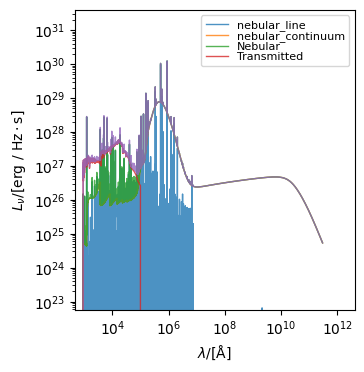

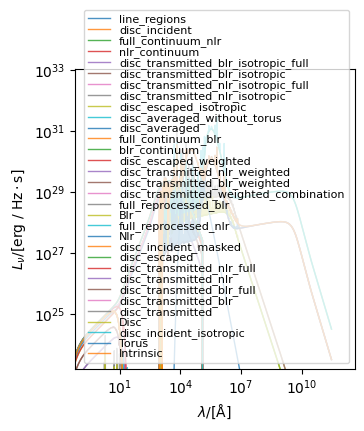

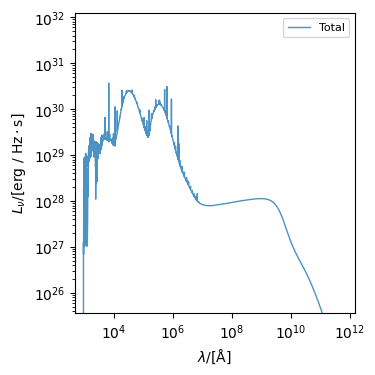

In [14]:
galaxy.stars.plot_spectra()
galaxy.black_holes.plot_spectra()
galaxy.plot_spectra()


In [ ]:
lines = galaxy.get_lines(stellar_grid.available_lines, total_emission_model)

/Users/sw376/Dropbox/Research/projects/synthesizer_projects/agn-workshop/venv/lib/python3.10/site-packages/unyt/array.py:1832: RuntimeWarning: overflow encountered in exp
  out_arr = func(np.asarray(inp), out=out_func, **kwargs)
/Users/sw376/Dropbox/Research/projects/synthesizer_projects/agn-workshop/venv/lib/python3.10/site-packages/unyt/array.py:1972: RuntimeWarning: overflow encountered in multiply
  out_arr = func(


## Type II